## FiftyOne 工具箱 — 综合参考文档

### 目录（TOC）

| 章节 | 内容 |
|------|------|
| [1. 数据集管理](##1-数据集管理) | 创建、加载、持久化、克隆、删除 |
| [2. 样本与字段](#2-样本与字段) | 样本增删改、字段增删改、元数据计算 |
| [3. 视图过滤](#3-视图过滤) | 字段过滤、标签过滤、排序与限制 |
| [4. 模型评估](#4-模型评估) | 模型应用、检测评估、评估管理 |
| [5. Brain 分析](#5-brain-分析) | Embedding、可视化、相似度、重复检测 |
| [6. 导入导出](#6-导入导出) | FiftyOne 格式备份与恢复 |


> **使用说明**：本文件是 API 速查手册，每章节对应一类操作。
> 工具类 notebook 请参考 `01_`~`12_` 各专题文件。


In [4]:
import fiftyone as fo  


In [ ]:

# 加载已存在的数据集
session = fo.launch_app(auto=False)
session

---

## 1. 数据集管理


### 创建和加载



In [ ]:
import fiftyone as fo  
import fiftyone.zoo as foz

# 创建空数据集  
dataset = fo.Dataset("my-dataset")

# # 从目录加载标准格式数据集  
# dataset = fo.Dataset.from_dir(  
#     dataset_dir="/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/00_test/00_try/raw_data",  
#     dataset_type=fo.types.COCODetectionDataset,  
#     name="my-dataset"  
# )

# # 从Zoo加载预定义数据集  
# dataset = foz.load_zoo_dataset("quickstart")


### 加载图片___和___部分label

In [ ]:
import fiftyone as fo

dataset_dir = "path/to/images"  # 替换为你的图片目录路径

# 从目录加载图片
dataset = fo.Dataset.from_dir(  
        dataset_dir=dataset_dir,
        dataset_type=fo.types.ImageDirectory,  
        name=f"{dataset_dir.split('/')[-1]}"  
    )

# dataset = fo.load_dataset("ms2_0605_0923")  # 加载上面创建的数据集
# 合并 COCO 标签到图片 
dataset.merge_dir(  
    dataset_type=fo.types.COCODetectionDataset,  
    data_path="/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/a04_whole_raw_data/ms2_0605_0923",  # 这个子集图片目录是必须的，因为它会用来匹配图片和标签
    labels_path="/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/00_pipeline/00_temp/del/labels.json",  
    label_field="ground_truth",  
)

### 遍历文件夹路径

In [ ]:
from pathlib import Path

raw_data_dir = "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/a01_20dataset"

sub_dir_path = ""

all_file_path_list = sorted(Path(raw_data_dir).glob(f"*/{sub_dir_path}"))

# 打印供主人确认，格式可直接粘贴进 list
for file_path in all_file_path_list:
    print(f'    "{file_path}",')

print(f"\n共 {len(all_file_path_list)} 个文件夹")

### 遍历FiftyOne Dataset name

In [ ]:
import fiftyone as fo  

# 列出所有数据集, 并设置为持久化
datasets_list = fo.list_datasets()
for dataset_name in datasets_list:
    print(f"    \"{dataset_name}\",")

### 持久化管理


In [7]:
import fiftyone as fo  

# 列出所有数据集, 并设置为持久化
datasets_list = fo.list_datasets()
for dataset_name in datasets_list:
    dataset = fo.load_dataset(dataset_name)
    # dataset.persistent = True
    print(f"\"{dataset.name:<80}|{dataset.persistent!s:>8}\",")
    # print(f"\"{dataset.name}\",")

"2024_SWD_seven_dataset                                                          |    True",
"2024_SWD_three_datasets                                                         |    True",
"2025_north_v1_ManualFocus_air1_0427-0611                                        |    True",
"2025_north_v1_ManualFocus_air1_0611-0727                                        |    True",
"2025_north_v1_ManualFocus_air1_0728-0921                                        |    True",
"2025_north_v1_ManualFocus_air2_0427-0611                                        |    True",
"2025_north_v1_ManualFocus_air2_0611-0725                                        |    True",
"2025_north_v1_ManualFocus_jeff_0425-0611                                        |    True",
"2025_north_v1_ManualFocus_jeff_0611-0711                                        |    True",
"2025_north_v1_ManualFocus_jeff_0717-0915                                        |    True",
"2025_north_v1_ManualFocus_jeff_0921-1108                             

In [8]:
import fiftyone as fo  

# 删除所有非持久化数据集
fo.delete_non_persistent_datasets(verbose=True)

In [ ]:
# 删除指定数据集
# fo.delete_dataset("sahi_null_run_rawData_v4_ms1_0726-0809_11")

# 删除多个数据集
datasets = [
    "test"
]
for ds in datasets:
    fo.delete_dataset(ds)

### 克隆数据集

In [ ]:
import fiftyone as fo

# 已有数据集
dataset = fo.load_dataset("test_run2_image")

# 复制一份，互不影响
dataset2 = dataset.clone(name="test_run2_image_copy")

---

## 2. 样本与字段


### 样本管理


In [ ]:
# 创建样本  
sample = fo.Sample(filepath="/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/00_test/00_try/raw_data/0719_0111_760.jpg")
print(sample)

In [ ]:
import fiftyone as fo

# 添加样本
dataset = fo.load_dataset("my-dataset")
dataset.add_sample(sample)  

In [ ]:
import fiftyone as fo

# 批量添加样本
filepaths = [
    "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/00_test/00_try/raw_data/0719_0111_760.jpg",
    "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/00_test/00_try/raw_data/0731_2037_760.jpg",
    # "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/00_test/00_try/raw_data/0731_2039_800.jpg",
    # "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/01_data/00_test/00_try/raw_data/0731_2242_800.jpg"
    ]
samples = [fo.Sample(filepath=f) for f in filepaths]  
dataset.add_samples(samples)  

In [ ]:
# 修改样本后保存  
sample.tags.append("test")
sample.save()

### 字段操作


In [ ]:
# 计算数据集元数据
dataset.compute_metadata()


In [ ]:
import fiftyone as fo
from fiftyone import ViewField as F

# 添加字段，左侧PRIMITIVES的变量
dataset = fo.load_dataset("my-dataset")
dataset.add_sample_field("confidence", fo.FloatField)  
print(dataset)

In [ ]:

# 将置信度下限设为0.5  
view = dataset.set_field(  
    "predictions.detections.confidence",   
    F("confidence").max(0.5)  
)
# 将view保存到数据集中，持久化
# view.save("confidence")                   # 保存view到当前视图。不推荐使用，因为覆盖了原始数据集
dataset.save_view("confidence_0.5", view)   # 保存view到新视图，持久化


In [ ]:
# 获取字段值
values = dataset.values("predictions.detections.confidence")
print(values)

In [ ]:
# 重命名字段
dataset.rename_sample_field("base_model", "ground_truth")

# 批量重命名多个字段  
dataset.rename_sample_fields({  
    "ground_truth": "new_label_field",  
    "predictions": "model_predictions"  
})

In [ ]:
# 删除字段
dataset.delete_sample_field("confidence")
print(dataset)


---

## 3. 视图过滤


### 字段过滤


In [ ]:
from fiftyone import ViewField as F  

# 创建视图  
view = dataset.view()
view

In [ ]:
# 过滤样本  
view = dataset.match(F("filepath").starts_with("/path"))
view

In [ ]:
# 限制和排序  
view = dataset.limit(2).sort_by("filepath")
view

In [ ]:
# 过滤数值字段  
view = dataset.filter_field("created_at", F() > 0)
view

In [ ]:
# 存在字段  
view = dataset.exists("predictions")
view

In [ ]:
# 更新视图到APP
session.view = view

### 标签过滤


In [ ]:
# 过滤标签  
dataset = fo.load_dataset("ms2_0726-0809_13_ok_v22")
view = dataset.filter_labels("01_swd_seg_results_coco", F("confidence") > 0.5)
view

In [ ]:
# 选择包含高置信度标签的样本  
view = dataset.match_labels(F("confidence") > 0.9)

In [ ]:
# 排除特定标签  
view = dataset.exclude_labels(tags="test")

In [ ]:
# 匹配标签  
view = dataset.match_tags("test")
view

In [ ]:
# 将多个动物标签映射为"animal"  
view = dataset.map_labels("predictions", {"cat": "animal", "dog": "animal"})

---

## 4. 模型评估


### 模型应用


In [ ]:
import fiftyone.zoo as foz
import fiftyone as fo
from ultralytics import YOLO
import fiftyone.utils.ultralytics as fou

# 加载模型  
# model = foz.load_zoo_model("clip-vit-base32-torch")
model = YOLO("yolo11s.pt")

# 应用模型
dataset = fo.load_dataset("my-dataset")
dataset.apply_model(model, label_field="predictions", confidence_thresh=0.1)

# 计算embeddings  
# embeddings = dataset.compute_embeddings(model)

### 模型评估


In [ ]:
# 评估检测模型  
results = dataset.evaluate_detections(  
    "predictions2",             # predictions field 
    gt_field="predictions2",    # ground truth field
    eval_key="eval2"  
)

In [ ]:
# 评估分类模型  
results = dataset.evaluate_classifications(  
    "predictions",  
    gt_field="ground_truth",  
    eval_key="eval"  
)

In [ ]:
# 删除指定评估键的评估  
dataset.delete_evaluation("eval_key_name")

In [ ]:
# 删除数据集上的所有评估  
datasets_list = [
    "sahi_null_v2_ms1_0605-0621_40_ok",
    "sahi_null_v2_ms1_0710-0726_36_ok",
    "sahi_null_v2_ms1_0726-0809_11_ok",
    "sahi_null_v2_ms1_0809-0823_34_ok",
    "sahi_null_v2_ms2_0726-0809_13_ok",
    "sahi_null_v2_ms2_0809-0823_10_ok",
    "sahi_null_v2_sw1_0605-0613_07_ok",
]
for dataset_name in datasets_list:
    print(f"Deleting evaluations for dataset: {dataset_name}")
    dataset = fo.load_dataset(dataset_name)
    dataset.delete_evaluations()

In [ ]:
# ===批量删除多个评估===

# 获取所有评估键  
eval_keys = dataset.list_evaluations()  

# 删除指定评估  
for eval_key in eval_keys:  
    if "specific_pattern" in eval_key:  # 可选的条件过滤  
        # dataset.delete_evaluation(eval_key)  
        print(f"已删除评估: {eval_key}")

## 标注工作流规范


### 标注流程


### 标签操作


---

## 5. Brain 分析


In [ ]:
# 列出所有可用的brain runs

print(dataset.list_brain_runs())

In [ ]:
# 删除brain run
for run in dataset.list_brain_runs():
    dataset.delete_brain_run(run)

### 可视化分析-embeddings


In [ ]:
import fiftyone.brain as fob 
import fiftyone.zoo as foz
from matplotlib import patches


# 计算embeddings  
model = foz.load_zoo_model("clip-vit-base32-torch")
emb_field = "embeddings2"
patches_field = "small_slices"  # 关键：按这个字段里的 bbox/mask 作为 patch
# dataset.compute_embeddings(model, embeddings_field=emb_field)
dataset.compute_patch_embeddings(
    model,
    patches_field=patches_field,   # 关键：按这个字段里的 bbox/mask 作为 patch
    embeddings_field=emb_field,
)

In [ ]:
# # 计算可视化  
# results = fob.compute_visualization(  
#     dataset,   
#     embeddings=emb_field,   
#     method="umap",   # 可选，pca, tsne, umap
#     brain_key=f"{emb_field}_vis",
#     seed=51,
# )

fob.compute_visualization(
    dataset,
    patches_field=patches_field,   # 告诉 brain 这是 patch 字段
    embeddings=emb_field,            # 用上一步算好的 embedding 字段
    method="umap",                # 先用 pca，规避 umap/numba 问题
    seed=51,
    brain_key=f"{emb_field}_vis2",  # 每个 dataset 自己有一份同名 brain_key 就行
)

In [ ]:
# 加载brain结果
results = dataset.load_brain_results("vis3")
results

### 按相似度排序

In [ ]:
import fiftyone.brain as fob

# Indexes the images in the dataset by visual similarity
fob.compute_similarity(dataset, brain_key="similarity")

In [ ]:
# 检测近似重复  
fob.compute_near_duplicates(dataset, threshold=0.95)  

In [ ]:
# 计算唯一性  
fob.compute_uniqueness(dataset)

In [ ]:
# 计算错误性  
fob.compute_mistakenness(dataset, "predictions", "ground_truth")

In [ ]:
import fiftyone.brain as fob 

# 检测重复
fob.compute_exact_duplicates(dataset)

In [ ]:
# 创建相似度索引  
fob.compute_similarity(  
    dataset,  
    embeddings=emb_field,  
    brain_key="similarity",  
    metric="cosine"  
)  

---

## 6. 导入导出


### 导出数据


In [ ]:
import fiftyone as fo
import os

root = "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/03_code/04_fiftyone/backup"
os.makedirs(root, exist_ok=True)

datasets = fo.list_datasets()
# datasets = ["00_try"]

for dataset_name in datasets:
    ds = fo.load_dataset(dataset_name)

    out = os.path.join(root, dataset_name)
    print("Backing up:", dataset_name)
    os.makedirs(out, exist_ok=True)

    ds.export(
        export_dir=out,
        dataset_type=fo.types.FiftyOneDataset,
        export_media=True,
    )


### 导入数据

In [ ]:
import fiftyone as fo
import os

# get name list
root = "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/03_code/04_fiftyone/backup"
name_list = os.listdir(root)
# name_list = ["00_try"]

for dataset_name in name_list:
    print(dataset_name)

    ds = fo.Dataset.from_dir(
        f"{root}/{dataset_name}",
        fo.types.FiftyOneDataset,
        name=dataset_name,
    )


## 🧹 FiftyOne 数据集修复（删除残留字段）

### 问题

在实验过程中，给 sample 写入了大量动态字段，例如：

```
fresh_small_slices_*_tp
fresh_small_slices_*_fp
fresh_small_slices_*_fn
```

这些字段：

* 被直接写进 MongoDB
* **没有注册到 FiftyOne schema**

导致重新打开数据集时报错：

```
FieldDoesNotExist
```

甚至：

```python
dataset.first()
```

都会直接崩溃。

---

### 原因

FiftyOne 是 **严格 schema**：

| 位置              | 状态     |
| --------------- | ------ |
| MongoDB         | ✅ 字段存在 |
| FiftyOne schema | ❌ 不认识  |

当 FiftyOne 读取 sample 时发现未知字段，就无法加载数据。

---

### 解决方法

因为 FiftyOne 已经无法正常读取 sample，
必须 **绕过 FiftyOne**，直接在 MongoDB 删除字段。

---

### 修复脚本如下


In [ ]:
import re
import fiftyone as fo

# ====== 修改这里即可 ======
dataset = fo.load_dataset("sahi_null_v2_ms1_0605-0621_40_ok")
FIELD_REGEX = r"^fresh_small_.*$"
# ==========================

sample_col = dataset._sample_collection
pattern = re.compile(FIELD_REGEX)

for doc in sample_col.find({}):
    stale_fields = [k for k in doc.keys() if pattern.match(k)]

    if not stale_fields:
        continue

    print("删除字段:", stale_fields[:5])

    unset_dict = {f: "" for f in stale_fields}
    sample_col.update_many({}, {"$unset": unset_dict})

dataset.reload()
print("✔ cleanup 完成")


## FiftyOne 导出所有字段 CSV
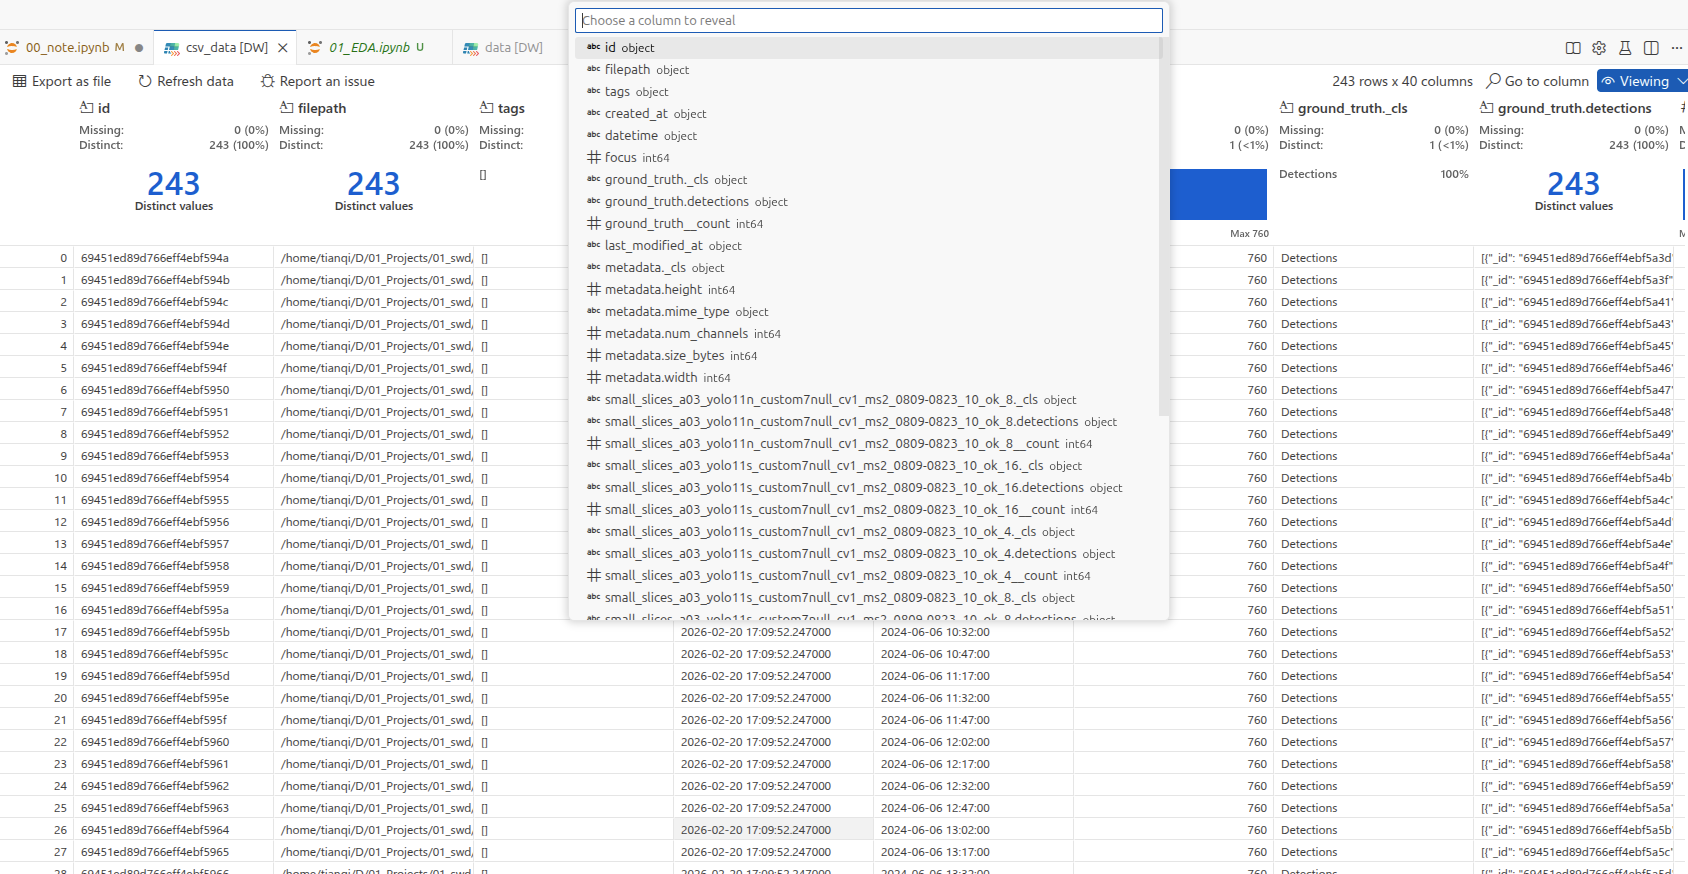

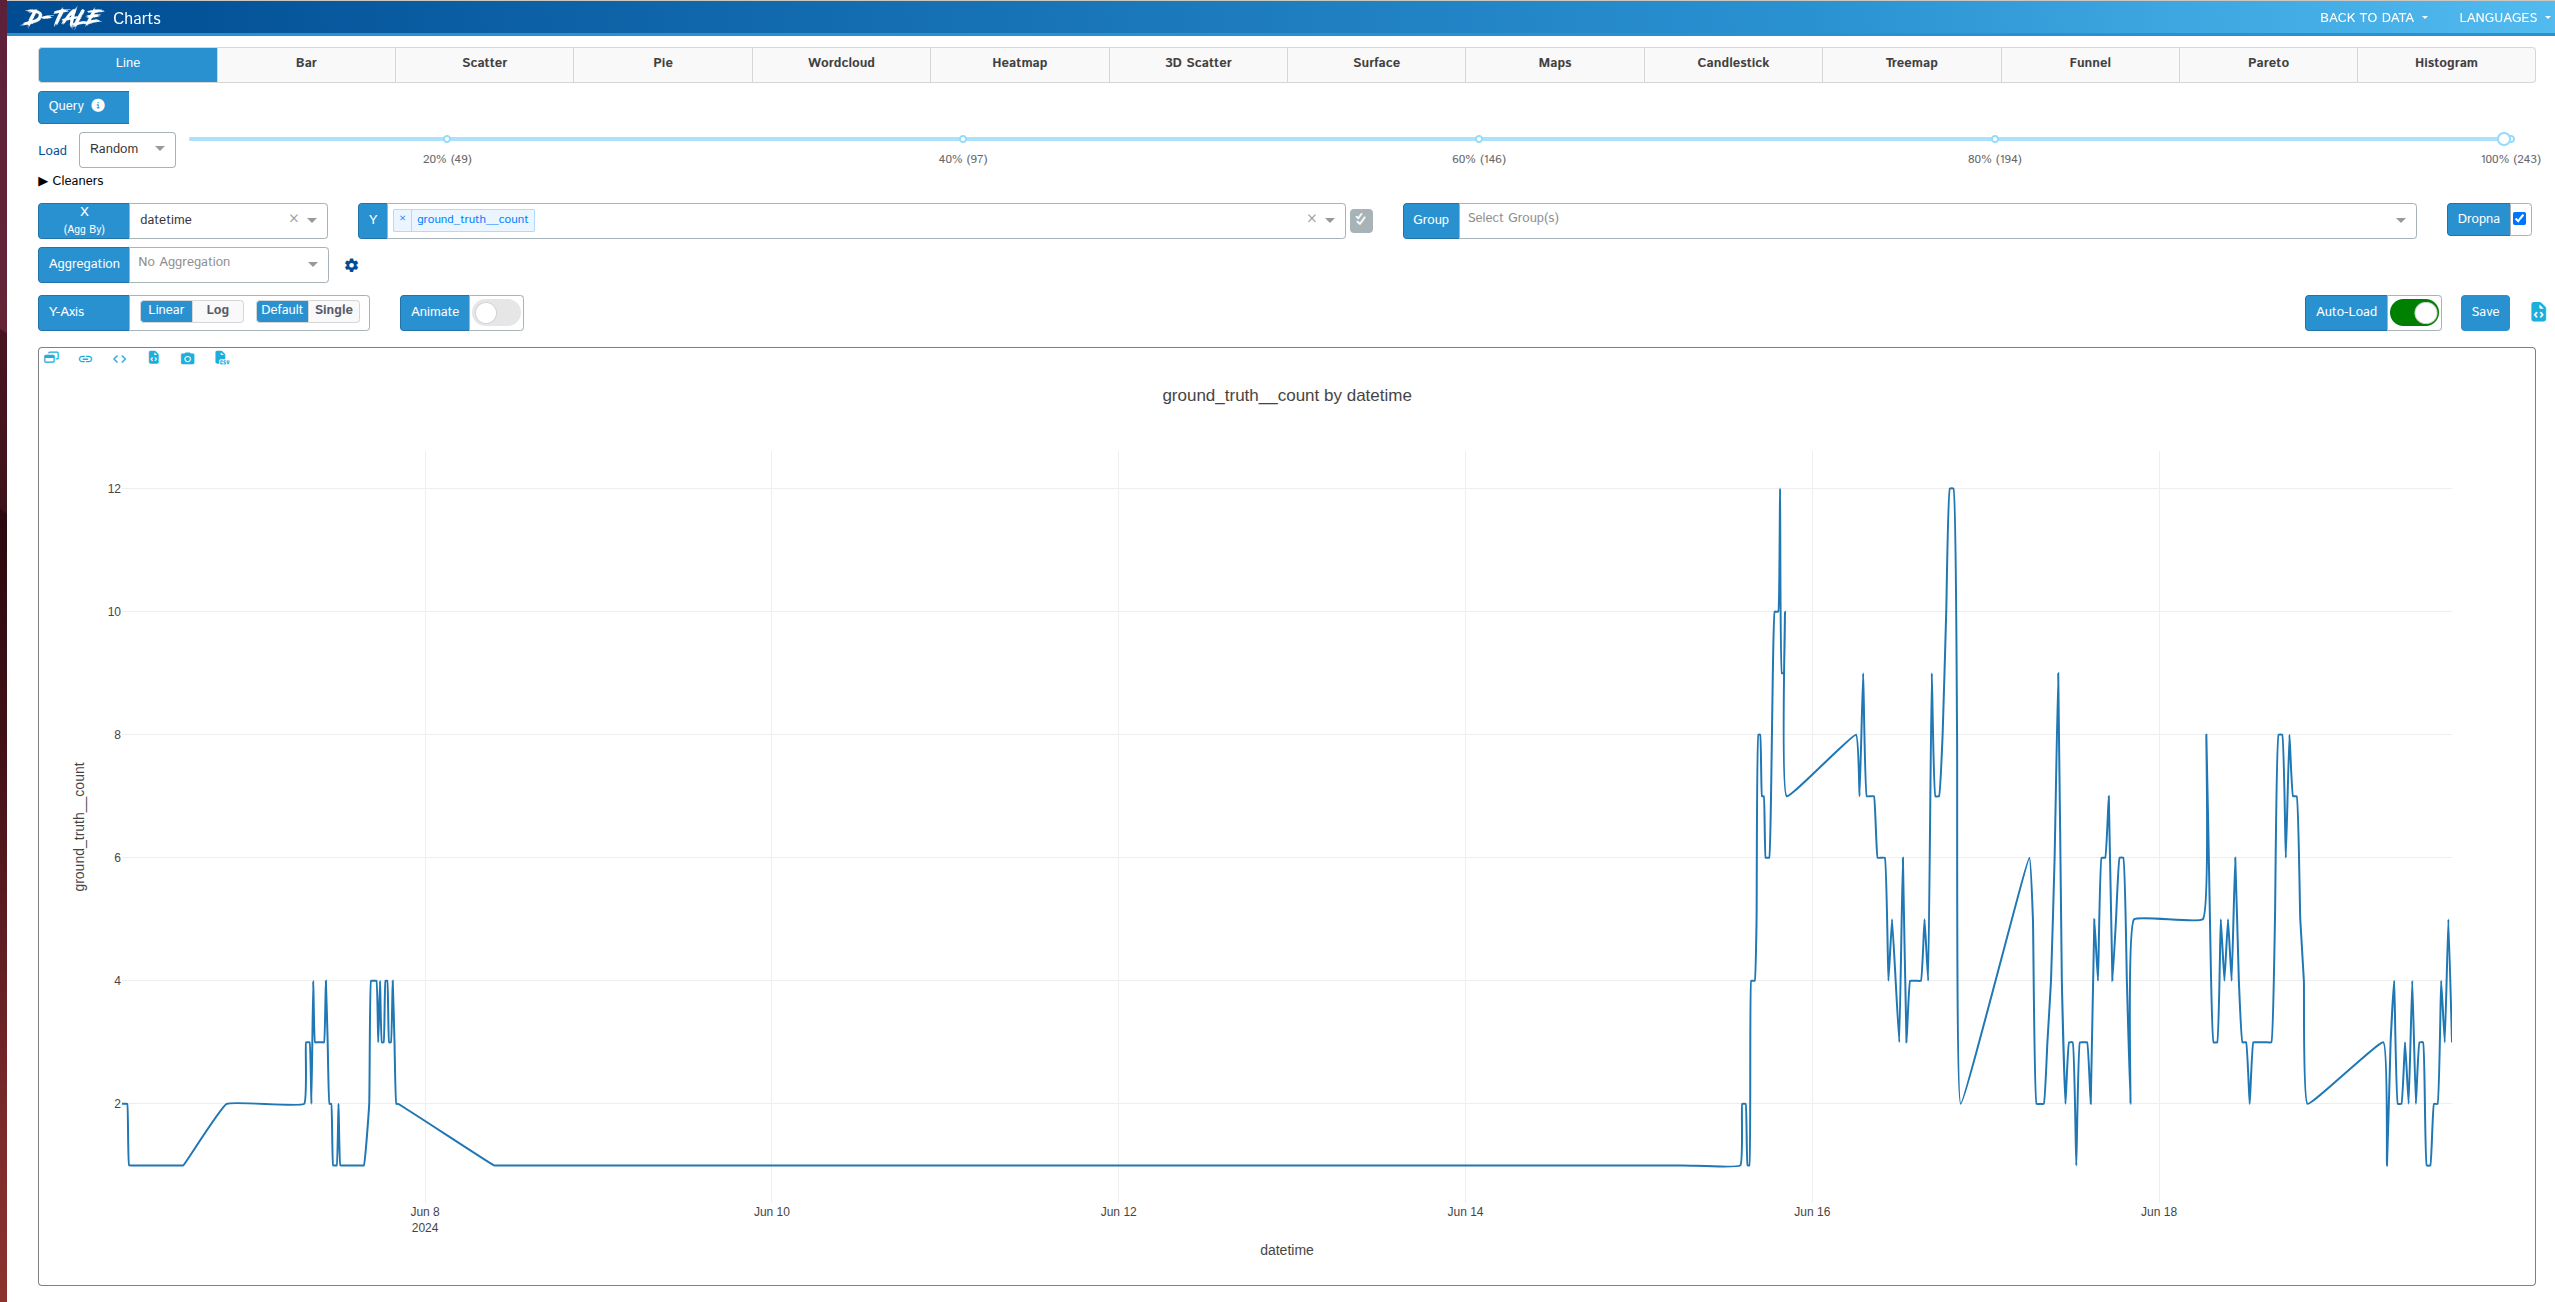

In [ ]:
import csv
import json
import fiftyone as fo
from fiftyone import EmbeddedDocumentField, ListField
import numpy as np
import os


def _serialize_value(val):
    """将单个值序列化为 CSV 友好的格式"""
    if val is None:
        return ""
    if isinstance(val, (int, float, bool, str)):
        return val
    if isinstance(val, np.ndarray):
        return json.dumps(val.tolist())
    # EmbeddedDocument（如 Classification 等）
    if hasattr(val, "to_dict"):
        return json.dumps(val.to_dict(), default=str)
    # list / tuple
    if isinstance(val, (list, tuple)):
        return json.dumps([_serialize_value(v) for v in val], default=str)
    return str(val)


def _flatten_doc(doc, schema, prefix=""):
    """
    递归展开一个 EmbeddedDocument，返回 {col_name: value} 的扁平字典。
    
    Args:
        doc:    EmbeddedDocument 实例（或 None）
        schema: 该 doc 对应的字段 schema（dict: field_name -> Field）
        prefix: 列名前缀
    """
    row = {}
    for field_name, field_obj in schema.items():
        col = f"{prefix}{field_name}" if prefix else field_name
        val = getattr(doc, field_name, None) if doc is not None else None

        if isinstance(field_obj, EmbeddedDocumentField):
            # 递归展开子文档
            sub_schema = field_obj.document_type._fields  # OrderedDict
            sub_row = _flatten_doc(val, sub_schema, prefix=col + ".")
            row.update(sub_row)

        elif isinstance(field_obj, ListField) and isinstance(
            field_obj.field, EmbeddedDocumentField
        ):
            # List[EmbeddedDocument]（如 Detections.detections）→ JSON
            if val is not None:
                row[col] = json.dumps(
                    [item.to_dict() for item in val], default=str
                )
            else:
                row[col] = ""

        else:
            row[col] = _serialize_value(val)

    return row


def export_dataset_to_csv(dataset: fo.Dataset, csv_path: str):
    """
    将 FiftyOne Dataset 导出为 CSV，每行一个 Sample，列为所有递归展开的字段。

    Args:
        dataset:  fo.Dataset 实例
        csv_path: 输出 CSV 文件路径
    """
    # 内置字段（id, filepath, tags, metadata 等）+ 用户自定义字段
    schema = dataset.get_field_schema(flat=False)  # {field_name: Field}

    # 先遍历一遍，收集所有列名（保证顺序稳定）
    all_columns = set()
    rows = []

    for sample in dataset:
        row = {}

        # 固定字段：id, filepath, tags
        row["id"] = str(sample.id)
        row["filepath"] = sample.filepath
        row["tags"] = json.dumps(sample.tags)

        # 遍历 schema 中所有字段
        for field_name, field_obj in schema.items():
            if field_name in ("id", "filepath", "tags"):
                continue  # 已处理
            val = sample.get_field(field_name)

            if isinstance(field_obj, EmbeddedDocumentField):
                sub_schema = field_obj.document_type._fields
                sub_row = _flatten_doc(val, sub_schema, prefix=field_name + ".")
                row.update(sub_row)

            elif isinstance(field_obj, ListField) and isinstance(
                field_obj.field, EmbeddedDocumentField
            ):
                row[field_name] = (
                    json.dumps([item.to_dict() for item in val], default=str)
                    if val else ""
                )

            else:
                row[field_name] = _serialize_value(val)

        all_columns.update(row.keys())
        rows.append(row)

    # 确定列顺序：固定列优先，其余按字母排序
    fixed_cols = ["id", "filepath", "tags"]
    other_cols = sorted(all_columns - set(fixed_cols))
    columns = fixed_cols + other_cols

    # 写入 CSV
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=columns, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            # 缺失列填空
            for col in columns:
                row.setdefault(col, "")
            writer.writerow(row)

    print(f"✅ 导出完成：{csv_path}，共 {len(rows)} 行，{len(columns)} 列")




In [ ]:
import dtale
import pandas as pd
# ── 使用示例 ──────────────────────────────────────────────
current_dataset = session.dataset  # 或 dataset
export_dataset_to_csv(current_dataset, "/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/03_code/04_fiftyone/tools/export/my_dataset_southfarm2_pct50.csv")


In [ ]:
import pandas as pd
import dtale
# load csv
csv_data = pd.read_csv("/home/tianqi/D/01_Projects/01_swd/02_code/pipeline/ultralytics_ty/_ty/03_code/04_fiftyone/tools/export/my_dataset.csv")
# datetime 列转换为 datetime 类型（如果有）
for col in csv_data.columns:
    if "date" in col.lower() or "time" in col.lower():
        csv_data[col] = pd.to_datetime(csv_data[col], errors="coerce")
dtale.show(csv_data).open_browser()
csv_data

## 导出APP的过滤视图到json___AND___加载过滤视图到APP
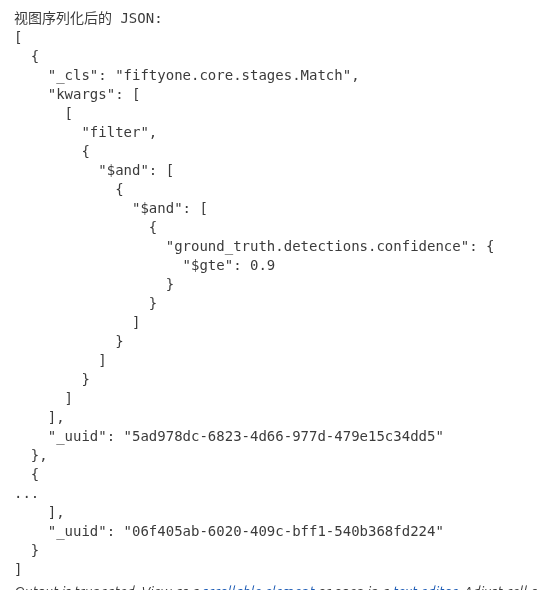

In [ ]:
import fiftyone as fo  
import json  

# 在 App 中应用一些过滤后，执行以下代码  
view = session.view  
if view is not None:  
    # 序列化视图为 stage 字典列表  
    view_json = view._serialize()  
    print("视图序列化后的 JSON:")  
    print(json.dumps(view_json, indent=2))
    # export view_json to file for later use
    with open("saved_view_filter_command.json", "w") as f:
        json.dump(view_json, f, indent=2)
else:  
    print("当前 App 未设置过滤视图")

In [ ]:
# 读取保存的视图 JSON 并重建视图
with open("view.json", "r") as f:
    view_json = json.load(f)
reconstructed_view = fo.DatasetView._build(session.dataset, view_json)
session.view = reconstructed_view

## 绘图表--dashboard

In [2]:
import fiftyone as fo
from fiftyone import ViewField as F
dataset = fo.load_dataset("TEST2_ms2_0605_0923")

/home/tianqi/miniconda3/envs/fif/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import numpy as np
import pandas as pd
from fiftyone import ViewField as F

dataset = ctx.view
threshold = 0.7
label = "pred_yolo11l_20pct_null_images_add_rawData_batch_4_final"
# label = "pred_yolo11m_20pct_null_images_add_rawData_batch_16_final"
view = dataset.filter_labels(label, F("confidence") > threshold, only_matches=False)
times, count = view.values(["datetime",F(f"{label}.detections").length()])

pairs = [(t.isoformat(), v) for t, v in zip(times, count) if t]

data = {
    "x": [p[0] for p in pairs],
    "y": [p[1] for p in pairs],
    "name": f"{ctx.dataset.name}_count_pct{int(threshold*100)}"
}
data